In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/harshitsaini07/project009/placement_full.csv


Dataset Preview:

   CGPA   IQ  Communication  Internships  Projects  Aptitude  TechnicalSkills  \
0   8.5  120              8            2         3        85                8   
1   7.2  110              7            1         2        75                7   
2   6.1   95              5            0         1        60                5   
3   9.0  130              9            3         4        90                9   
4   5.8   85              4            0         1        55                4   

   Placed  
0       1  
1       1  
2       0  
3       1  
4       0  

Dataset Shape: (15, 8)

Missing Values:

CGPA               0
IQ                 0
Communication      0
Internships        0
Projects           0
Aptitude           0
TechnicalSkills    0
Placed             0
dtype: int64

Features Used:
['CGPA', 'IQ', 'Communication', 'Internships', 'Projects', 'Aptitude', 'TechnicalSkills']

Feature Importance Scores:

           Feature      Score
5         Aptitude  51.214388
1    

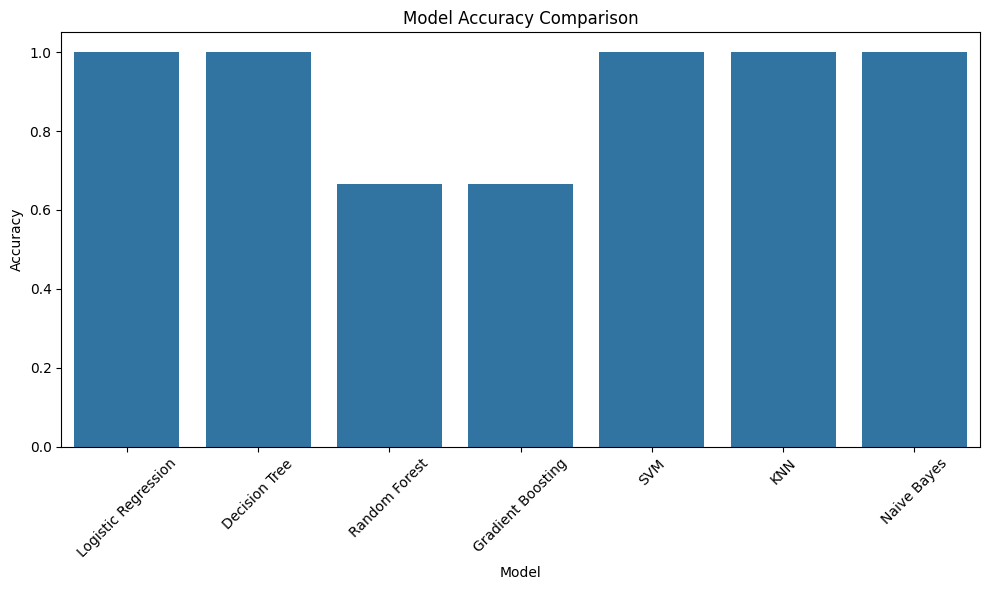

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

# Classification Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# =========================
# LOAD DATASET
# =========================

df = pd.read_csv("/kaggle/input/datasets/harshitsaini07/project009/placement_full.csv")

print("Dataset Preview:\n")
print(df.head())

print("\nDataset Shape:", df.shape)
print("\nMissing Values:\n")
print(df.isnull().sum())

# =========================
# FEATURES AND TARGET
# =========================

X = df.drop("Placed", axis=1)
y = df["Placed"]

print("\nFeatures Used:")
print(X.columns.tolist())

# =========================
# FEATURE SELECTION
# =========================

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
})

print("\nFeature Importance Scores:\n")
print(feature_scores.sort_values(by="Score", ascending=False))

# =========================
# TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# =========================
# FEATURE SCALING
# =========================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# MODELS
# =========================

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

results = []

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

    print(f"\n{name}")
    print("Accuracy :", round(accuracy * 100, 2), "%")
    print("Precision:", round(precision * 100, 2), "%")
    print("Recall   :", round(recall * 100, 2), "%")
    print("F1 Score :", round(f1 * 100, 2), "%")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

# =========================
# FINAL RESULT TABLE
# =========================

result_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

print("\n==============================")
print("FINAL RESULT TABLE")
print("==============================")
print(result_df)

# =========================
# BEST MODEL
# =========================

best_model = result_df.loc[result_df["Accuracy"].idxmax()]

print("\n==============================")
print("BEST MODEL")
print("==============================")
print(best_model)

# =========================
# VISUALIZATION
# =========================

plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="Accuracy", data=result_df)

plt.title("Model Accuracy Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()